<a href="https://colab.research.google.com/github/unVeroz007/KumpulTugas/blob/main/Tugas_JST_Pertemuan_7_Muhammad_Galid_Avero_2311532008_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Instalasi dan Import Library

In [1]:
!pip install -q scikit-learn joblib

# import library
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import joblib

In [2]:
# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

#Membaca dan Menampilkan Dataset

In [16]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
print("Shape:", df.shape)
display(df.head())

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


#Eksplorasi Data Awal (EDA - Exploratory Data Analysis)

In [4]:
print("\nInfo:")
print(df.info())
print("\nUnique values per column (contoh beberapa kolom):")
for c in df.columns:
    print(c, "->", df[c].nunique(), "unique")

# Lihat distribusi kelas target
print("\nDistribusi target:")
print(df['NObeyesdad'].value_counts())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                        

#Pemisahan Fitur dan Label

In [5]:
# Target adalah 'NObeyesdad' sesuai instruksi
target_col = 'NObeyesdad'
X = df.drop(columns=[target_col])
y = df[target_col].copy()

#Identifikasi Tipe Data dan Encoding Kategorikal

In [17]:
# Pisahkan kolom numerik dan kategorikal
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

# One-hot encode categorical feature (drop_first True optional)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

Numeric cols: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorical cols: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


#Encoding Label Target

In [18]:
# Encode label target
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}


#Pembagian Data Training dan Testing

In [8]:
# Split data (stratify untuk menjaga distribusi kelas)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

#Normalisasi Data Numerik (Standarisasi)

In [9]:
# Scaling numeric columns
scaler = StandardScaler()
numeric_after = X_encoded.select_dtypes(include=['int64','float64']).columns.tolist()
X_train[numeric_after] = scaler.fit_transform(X_train[numeric_after])
X_test[numeric_after]  = scaler.transform(X_test[numeric_after])

#Membangun Arsitektur Neural Network

In [10]:
input_dim = X_train.shape[1]
n_classes = len(np.unique(y_enc))

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),   # hidden layer 1 (jumlah neuron bisa diubah)
    layers.Dense(32, activation='relu'),   # hidden layer 2
    layers.Dense(n_classes, activation='softmax')  # output softmax untuk multi-class
])


#Kompilasi Model

In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,847 (15.03 KB)

 Trainable params: 3,847 (15.03 KB)

 Non-trainable params: 0 (0.00 B)

#Pelatihan Model (Training)

In [12]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/100
45/45 - 2s - 44ms/step - accuracy: 0.3731 - loss: 1.7147 - val_accuracy: 0.4606 - val_loss: 1.5346
Epoch 2/100
45/45 - 0s - 7ms/step - accuracy: 0.5495 - loss: 1.3203 - val_accuracy: 0.5866 - val_loss: 1.2171
Epoch 3/100
45/45 - 0s - 6ms/step - accuracy: 0.6430 - loss: 1.0267 - val_accuracy: 0.6457 - val_loss: 0.9964
Epoch 4/100
45/45 - 1s - 16ms/step - accuracy: 0.7008 - loss: 0.8354 - val_accuracy: 0.6929 - val_loss: 0.8496
Epoch 5/100
45/45 - 0s - 8ms/step - accuracy: 0.7650 - loss: 0.7018 - val_accuracy: 0.7756 - val_loss: 0.7059
Epoch 6/100
45/45 - 1s - 14ms/step - accuracy: 0.8250 - loss: 0.5938 - val_accuracy: 0.8150 - val_loss: 0.6165
Epoch 7/100
45/45 - 0s - 8ms/step - accuracy: 0.8550 - loss: 0.5049 - val_accuracy: 0.8228 - val_loss: 0.5306
Epoch 8/100
45/45 - 0s - 9ms/step - accuracy: 0.8794 - loss: 0.4363 - val_accuracy: 0.8661 - val_loss: 0.4664
Epoch 9/100
45/45 - 1s - 11ms/step - accuracy: 0.9010 - loss: 0.3811 - val_accuracy: 0.8976 - val_loss: 0.4174
Epoch 

#Evaluasi Model dan Laporan Klasifikasi

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
print(f"Test accuracy (keras): {test_acc:.4f}, Accuracy (sklearn): {acc:.4f}, F1-macro: {f1_macro:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Test accuracy (keras): 0.9480, Accuracy (sklearn): 0.9480, F1-macro: 0.9458

Classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      1.00      0.96        54
      Normal_Weight       0.89      0.84      0.87        58
     Obesity_Type_I       0.97      0.99      0.98        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.89      0.86      0.88        58
Overweight_Level_II       0.95      0.97      0.96        58

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423



#Visualisasi Proses Pelatihan

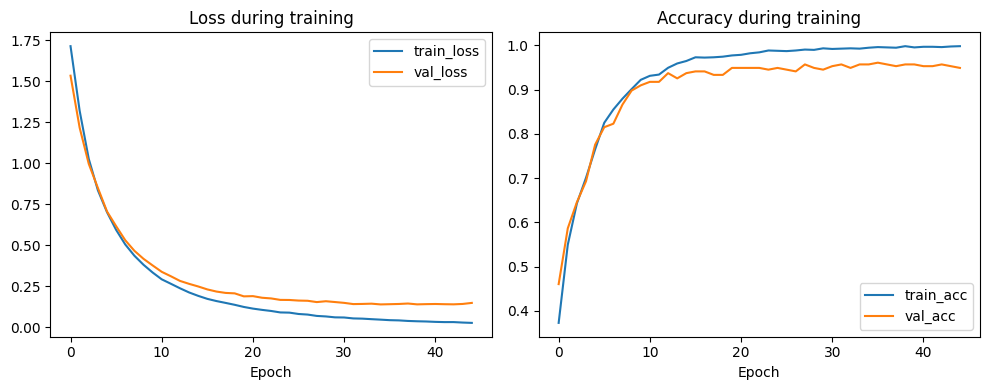

In [14]:
# Plot training history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss during training')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy during training')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

#Visualisasi Confusion Matrix

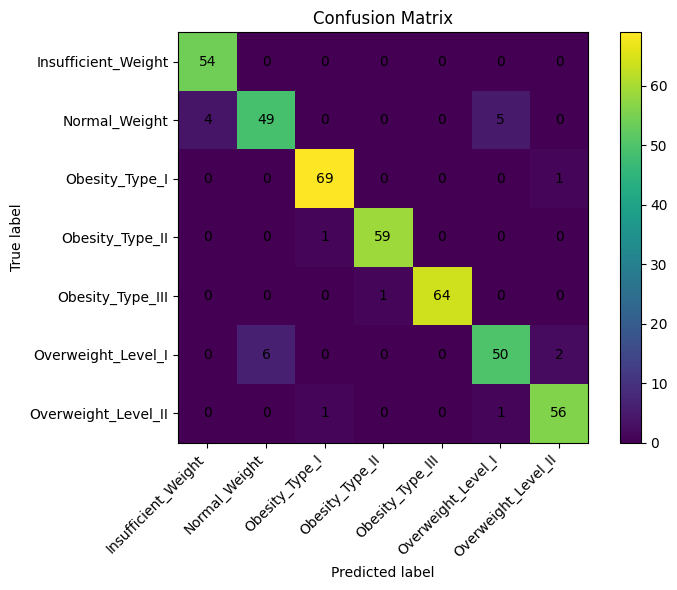

In [15]:
# Confusion matrix gambar
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(np.arange(len(le.classes_)), le.classes_, rotation=45, ha='right')
plt.yticks(np.arange(len(le.classes_)), le.classes_)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.show()